# Customer Churn Predictive Analysis



---
## PHASE 1 : SETUP & DATA LOADING
---

### 1.1 Install & Import Libraries

In [14]:
# ---------- Install imbalanced-learn (for SMOTE) ----------
# Works on both Kaggle and Google Colab.
!pip install -q imbalanced-learn

In [15]:
# ============================================================
# IMPORT ALL REQUIRED LIBRARIES
# ============================================================

# --- Data Manipulation ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing ---
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# --- Machine Learning Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

# --- Imbalanced Data Handling ---
from imblearn.over_sampling import SMOTE

# --- Utility ---
import warnings
warnings.filterwarnings('ignore')

# --- Plot Style ---
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully!')

All libraries imported successfully!


### 1.2 Load the Dataset

**Two ways to run this notebook:**

| Platform | How to load data |
|----------|-----------------|
| **Kaggle Notebook** | Click "Add Data" (right panel) → search "Netflix Customer Churn" → Add → dataset auto-loads at `/kaggle/input/` |
| **Google Colab** | Run the cell below → upload the CSV when prompted |

In [16]:
# ============================================================
# LOAD DATASET — Works on BOTH Kaggle and Google Colab
# ============================================================
import os
import glob

df_raw = None

# --- METHOD 1: Kaggle Notebook ---
kaggle_path = '/kaggle/input'
if os.path.exists(kaggle_path):
    # Show all files so we can see what's available
    print('Files found in /kaggle/input/:')
    for root, dirs, files_list in os.walk(kaggle_path):
        for f in files_list:
            full_path = os.path.join(root, f)
            print(f'  {full_path}')

    # Find all CSV files
    csv_files = glob.glob(f'{kaggle_path}/**/*.csv', recursive=True)

    # If no CSV found, also check for xlsx/xls files
    if not csv_files:
        csv_files = glob.glob(f'{kaggle_path}/**/*.xlsx', recursive=True)
        csv_files += glob.glob(f'{kaggle_path}/**/*.xls', recursive=True)

    if csv_files:
        filename = csv_files[0]
        if filename.endswith('.csv'):
            df_raw = pd.read_csv(filename)
        else:
            df_raw = pd.read_excel(filename)
        print(f'\n[Kaggle] Dataset loaded: {filename}')
    else:
        print('\nERROR: No CSV/Excel files found in /kaggle/input/')
        print('Make sure you added the dataset via "Add Input" button.')

# --- METHOD 2: Google Colab (upload file) ---
if df_raw is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        df_raw = pd.read_csv(filename)
        print(f'[Colab] Dataset loaded: {filename}')
    except ImportError:
        pass

# --- METHOD 3: Manual fallback ---
if df_raw is None:
    print('\nDataset not loaded automatically.')
    print('Uncomment the line below and set the correct path:')
    print('# df_raw = pd.read_csv("/kaggle/input/YOUR-DATASET-FOLDER/filename.csv")')
    raise FileNotFoundError('Please load the dataset using one of the methods above.')

# Keep an untouched copy
df = df_raw.copy()

print(f'\nRows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Files found in /kaggle/input/:
  /kaggle/input/netflix-customer-churn-and-engagement-dataset/netflix_large_user_data.xlsx

[Kaggle] Dataset loaded: /kaggle/input/netflix-customer-churn-and-engagement-dataset/netflix_large_user_data.xlsx

Rows   : 1000
Columns: 16


---
## PHASE 2 : DATA EXPLORATION
---

### 2.1 Preview the Data

In [17]:
# ============================================================
# FIRST LOOK AT THE DATA
# Each row = one Netflix customer; columns = attributes.
# ============================================================
df.head()

,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


In [18]:
# ============================================================
# COLUMN NAMES & DATA TYPES
# Identify which columns are numeric vs categorical.
# ============================================================
print(f'Total columns: {df.shape[1]}\n')
df.info()

Total columns: 16

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer ID                         1000 non-null   object 
 1   Subscription Length (Months)        1000 non-null   int64  
 2   Customer Satisfaction Score (1-10)  1000 non-null   int64  
 3   Daily Watch Time (Hours)            1000 non-null   float64
 4   Engagement Rate (1-10)              1000 non-null   int64  
 5   Device Used Most Often              1000 non-null   object 
 6   Genre Preference                    1000 non-null   object 
 7   Region                              1000 non-null   object 
 8   Payment History (On-Time/Delayed)   1000 non-null   object 
 9   Subscription Plan                   1000 non-null   object 
 10  Churn Status (Yes/No)               1000 non-null   object 
 11  Support Queries Logged   

In [19]:
# ============================================================
# STATISTICAL SUMMARY OF NUMERIC COLUMNS
# Shows min, max, mean, std dev — helps spot outliers.
# ============================================================
df.describe()

,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,9.17700,5.379000,2.829420,5.511000,4.951000,43.840000,5251.452000,2.422000,2.937000
std,8.21859,2.856487,1.302673,2.871607,3.111636,15.356439,2720.859072,1.689607,1.430062
min,1.00000,1.000000,0.500000,1.000000,0.000000,18.000000,510.000000,0.000000,1.000000
25%,3.00000,3.000000,1.650000,3.000000,2.000000,30.000000,3073.250000,1.000000,2.000000
50%,6.00000,5.000000,2.890000,6.000000,5.000000,44.000000,5286.000000,2.000000,3.000000
75%,12.00000,8.000000,3.932500,8.000000,8.000000,57.000000,7598.250000,4.000000,4.000000
max,24.00000,10.000000,5.000000,10.000000,10.000000,70.000000,9994.000000,5.000000,5.000000


In [20]:
# ============================================================
# UNIQUE VALUES IN EACH COLUMN
# Helps understand cardinality of categorical features.
# ============================================================
for col in df.columns:
    print(f'{col:35s} -> {df[col].nunique():5d} unique  |  Sample: {df[col].unique()[:5]}')

Customer ID                         ->  1000 unique  |  Sample: ['C00001' 'C00002' 'C00003' 'C00004' 'C00005']
Subscription Length (Months)        ->     5 unique  |  Sample: [12  3 24  6  1]
Customer Satisfaction Score (1-10)  ->    10 unique  |  Sample: [10  8  4  7  2]
Daily Watch Time (Hours)            ->   406 unique  |  Sample: [4.85 1.75 2.75 3.   1.37]
Engagement Rate (1-10)              ->    10 unique  |  Sample: [4 9 5 3 2]
Device Used Most Often              ->     5 unique  |  Sample: ['Tablet' 'Laptop' 'Smart TV' 'Mobile' 'Desktop']
Genre Preference                    ->     7 unique  |  Sample: ['Action' 'Thriller' 'Comedy' 'Drama' 'Romance']
Region                              ->     5 unique  |  Sample: ['Europe' 'Asia' 'North America' 'Africa' 'South America']
Payment History (On-Time/Delayed)   ->     2 unique  |  Sample: ['On-Time' 'Delayed']
Subscription Plan                   ->     3 unique  |  Sample: ['Basic' 'Premium' 'Standard']
Churn Status (Yes/No)        

### 2.2 Check Missing Values

In [21]:
# ============================================================
# MISSING VALUES CHECK
# ============================================================
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) == 0:
    print('No missing values found! Dataset is clean.')
else:
    print('Columns with missing values:')
    print(missing_df)

print(f'\nTotal missing values: {df.isnull().sum().sum()}')

No missing values found! Dataset is clean.

Total missing values: 0


### 2.3 Target Variable Distribution (Class Imbalance Check)

Target column detected: "Churn Status (Yes/No)"
Unique values: ['No' 'Yes']

Churn Distribution:
  Yes             : 539  (53.9%)
  No              : 461  (46.1%)

  >>> Dataset is fairly BALANCED (54% / 46%)
  >>> SMOTE will still be applied for best results.


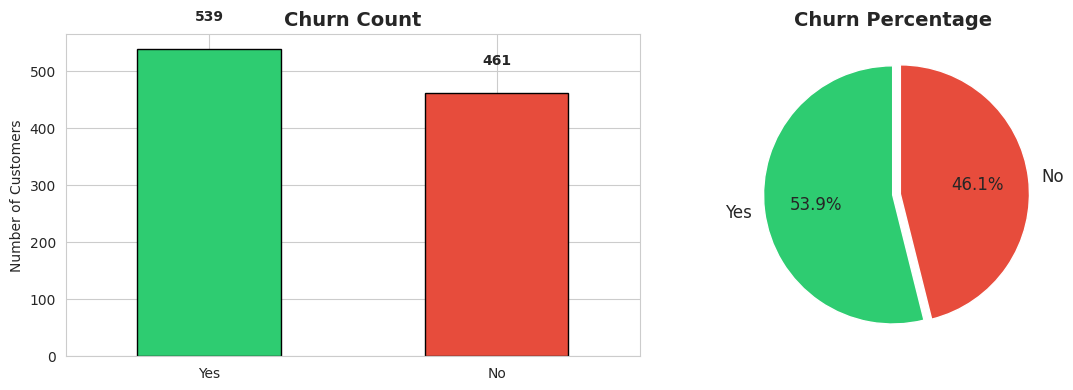

In [22]:
# ============================================================
# CHURN DISTRIBUTION
# The target column is 'Churn Status' in the Netflix dataset.
# We auto-detect the target column name.
# ============================================================

# Auto-detect the churn/target column
churn_col_candidates = [c for c in df.columns if 'churn' in c.lower()]
TARGET_COL = churn_col_candidates[0] if churn_col_candidates else df.columns[-1]
print(f'Target column detected: "{TARGET_COL}"')
print(f'Unique values: {df[TARGET_COL].unique()}')

churn_counts = df[TARGET_COL].value_counts()
churn_pct = df[TARGET_COL].value_counts(normalize=True) * 100

print(f'\nChurn Distribution:')
for label in churn_counts.index:
    print(f'  {label:15s} : {churn_counts[label]:,}  ({churn_pct[label]:.1f}%)')

# Check imbalance
majority_pct = churn_pct.max()
if majority_pct > 65:
    print(f'\n  >>> Dataset is IMBALANCED — majority class is {majority_pct:.0f}%')
    print('  >>> We will use SMOTE to balance it before training.')
else:
    print(f'\n  >>> Dataset is fairly BALANCED ({majority_pct:.0f}% / {100-majority_pct:.0f}%)')
    print('  >>> SMOTE will still be applied for best results.')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#e74c3c']

churn_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.06 if i == 1 else 0 for i in range(len(churn_counts))],
            textprops={'fontsize': 12})
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## PHASE 3 : DATA CLEANING & PREPROCESSING
---

### 3.1 Handle Missing Values

In [23]:
# ============================================================
# HANDLE MISSING VALUES
# Numeric columns  -> fill with median
# Categorical columns -> fill with mode (most frequent)
# ============================================================

numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all = df.select_dtypes(include='object').columns.tolist()

# Fill numeric missing with median
for col in numeric_cols_all:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Filled {col} with median: {median_val}')

# Fill categorical missing with mode
for col in cat_cols_all:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  Filled {col} with mode: {mode_val}')

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')


Remaining missing values: 0


### 3.2 Drop Irrelevant Columns

In [24]:
# ============================================================
# DROP ID COLUMN
# The Customer ID is a unique identifier — not predictive.
# We save it for later Power BI export.
# ============================================================

# Auto-detect ID column
id_col_candidates = [c for c in df.columns if 'id' in c.lower() and df[c].nunique() == len(df)]
if id_col_candidates:
    ID_COL = id_col_candidates[0]
    customer_ids = df[ID_COL].copy()
    df.drop(ID_COL, axis=1, inplace=True)
    print(f'Dropped ID column: "{ID_COL}"')
else:
    customer_ids = pd.Series(range(len(df)), name='CustomerIndex')
    print('No ID column found. Using row index as identifier.')

print(f'Remaining columns: {df.shape[1]}')

Dropped ID column: "Customer ID"
Remaining columns: 15


### 3.3 Encode Target Variable

In [25]:
# ============================================================
# ENCODE TARGET VARIABLE
# Convert Churn Status to binary: 1 = Churned, 0 = Stayed
# ============================================================

print(f'Target column: "{TARGET_COL}"')
print(f'Original values: {df[TARGET_COL].unique()}')

# If values are Yes/No or Churned/Stayed, map to 1/0
unique_vals = df[TARGET_COL].unique()
if df[TARGET_COL].dtype == 'object':
    # Find which value represents churn
    churn_labels = [v for v in unique_vals if any(kw in str(v).lower() for kw in ['yes', 'churn', 'true', '1'])]
    no_churn_labels = [v for v in unique_vals if v not in churn_labels]

    mapping = {}
    for v in churn_labels:
        mapping[v] = 1
    for v in no_churn_labels:
        mapping[v] = 0

    df[TARGET_COL] = df[TARGET_COL].map(mapping)
    print(f'Mapping: {mapping}')
else:
    print('Target is already numeric.')

print(f'Encoded values: {df[TARGET_COL].unique()}')
print(f'Churn (1): {(df[TARGET_COL] == 1).sum()}')
print(f'No Churn (0): {(df[TARGET_COL] == 0).sum()}')

Target column: "Churn Status (Yes/No)"
Original values: ['No' 'Yes']
Mapping: {'Yes': 1, 'No': 0}
Encoded values: [0 1]
Churn (1): 539
No Churn (0): 461


### 3.4 Encode Categorical Features

In [26]:
# ============================================================
# ENCODE CATEGORICAL FEATURES
# ML models need numeric input. We use LabelEncoder to convert
# text categories into numbers.
#
# Netflix dataset categorical columns include:
# - Device Used Most Often (Smart TV, Mobile, Laptop, Tablet)
# - Genre Preference (Action, Drama, Comedy, Sci-Fi, etc.)
# - Region (North America, Europe, Asia, etc.)
# - Payment History (On-time, Delayed)
# - Subscription Plan (Basic, Standard, Premium)
# ============================================================

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode ({len(categorical_cols)}):')

encoding_map = {}
le = LabelEncoder()

for col in categorical_cols:
    original_values = df[col].unique()
    df[col] = le.fit_transform(df[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col}: {encoding_map[col]}')

print(f'\nAll categorical columns encoded!')
print(f'Final dataset shape: {df.shape}')
df.head()

Categorical columns to encode (5):
  Device Used Most Often: {'Desktop': np.int64(0), 'Laptop': np.int64(1), 'Mobile': np.int64(2), 'Smart TV': np.int64(3), 'Tablet': np.int64(4)}
  Genre Preference: {'Action': np.int64(0), 'Comedy': np.int64(1), 'Documentary': np.int64(2), 'Drama': np.int64(3), 'Romance': np.int64(4), 'Sci-Fi': np.int64(5), 'Thriller': np.int64(6)}
  Region: {'Africa': np.int64(0), 'Asia': np.int64(1), 'Europe': np.int64(2), 'North America': np.int64(3), 'South America': np.int64(4)}
  Payment History (On-Time/Delayed): {'Delayed': np.int64(0), 'On-Time': np.int64(1)}
  Subscription Plan: {'Basic': np.int64(0), 'Premium': np.int64(1), 'Standard': np.int64(2)}

All categorical columns encoded!
Final dataset shape: (1000, 15)


,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,12,10,4.85,4,4,0,2,1,0,0,10,33,6250,5,2
1,12,8,1.75,9,1,6,2,1,0,1,9,28,7018,1,5
2,3,4,2.75,9,3,1,1,1,1,1,3,18,1055,1,5
3,3,7,3.00,9,3,3,2,0,1,0,5,32,6707,5,4
4,24,2,1.37,5,2,3,3,1,2,1,2,59,1506,3,5


### 3.5 Feature Scaling

In [27]:
# ============================================================
# FEATURE SCALING (StandardScaler)
# Logistic Regression is sensitive to feature magnitudes.
# Features like Monthly Income, Subscription Length, Age
# have very different scales — scaling normalizes them.
# ============================================================

# Separate features (X) and target (y)
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

# Identify numeric columns that need scaling (continuous features)
# These are columns with more than 10 unique values (not binary/ordinal)
numeric_cols = [col for col in X.columns if X[col].nunique() > 10]
print(f'Numeric columns to scale: {numeric_cols}')

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(f'\nScaled {len(numeric_cols)} numeric features.')
print(f'Feature matrix shape: {X.shape}')
X[numeric_cols].describe().round(2)

Numeric columns to scale: ['Daily Watch Time (Hours)', 'Support Queries Logged', 'Age', 'Monthly Income ($)']

Scaled 4 numeric features.
Feature matrix shape: (1000, 14)


,Daily Watch Time (Hours),Support Queries Logged,Age,Monthly Income ($)
count,1000.00,1000.00,1000.00,1000.00
mean,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.79,-1.59,-1.68,-1.74
25%,-0.91,-0.95,-0.90,-0.80
50%,0.05,0.02,0.01,0.01
75%,0.85,0.98,0.86,0.86
max,1.67,1.62,1.70,1.74


---
## PHASE 4 : EXPLORATORY DATA ANALYSIS (EDA)
---

### 4.1 Churn by Key Categorical Features

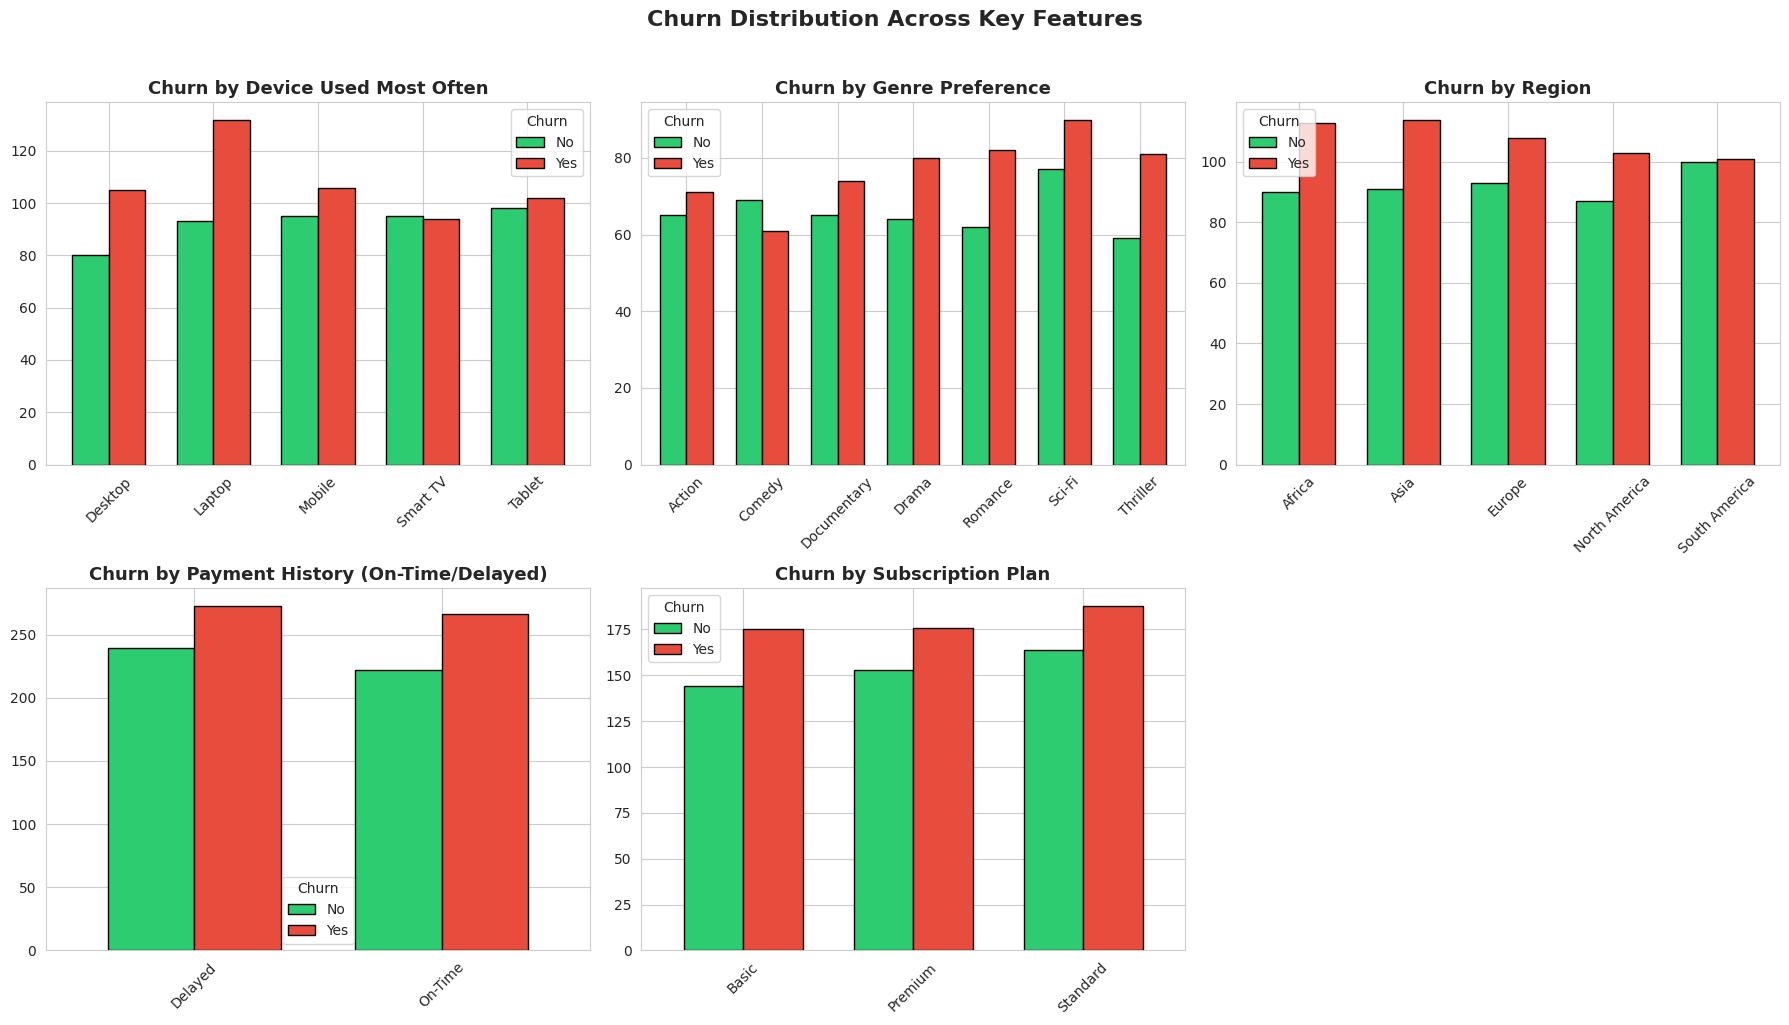

In [28]:
# ============================================================
# EDA CHART 1: CHURN BY KEY CATEGORICAL FEATURES
# Netflix features: Subscription Plan, Device, Genre,
# Region, Payment History
# ============================================================

df_viz = df_raw.copy()

# Auto-detect categorical columns from raw data (excluding ID & target)
viz_cat_cols = df_viz.select_dtypes(include='object').columns.tolist()
viz_cat_cols = [c for c in viz_cat_cols if c != TARGET_COL and 'id' not in c.lower()]

# Plot up to 6 categorical features
plot_cols = viz_cat_cols[:6]
n_plots = len(plot_cols)
n_rows = (n_plots + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten() if n_plots > 3 else [axes] if n_plots == 1 else axes.flatten()

for i, col in enumerate(plot_cols):
    ct = pd.crosstab(df_viz[col], df_viz[TARGET_COL])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='black', width=0.7)
    axes[i].set_title(f'Churn by {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(title='Churn')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Distribution Across Key Features',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Churn by Numeric Features

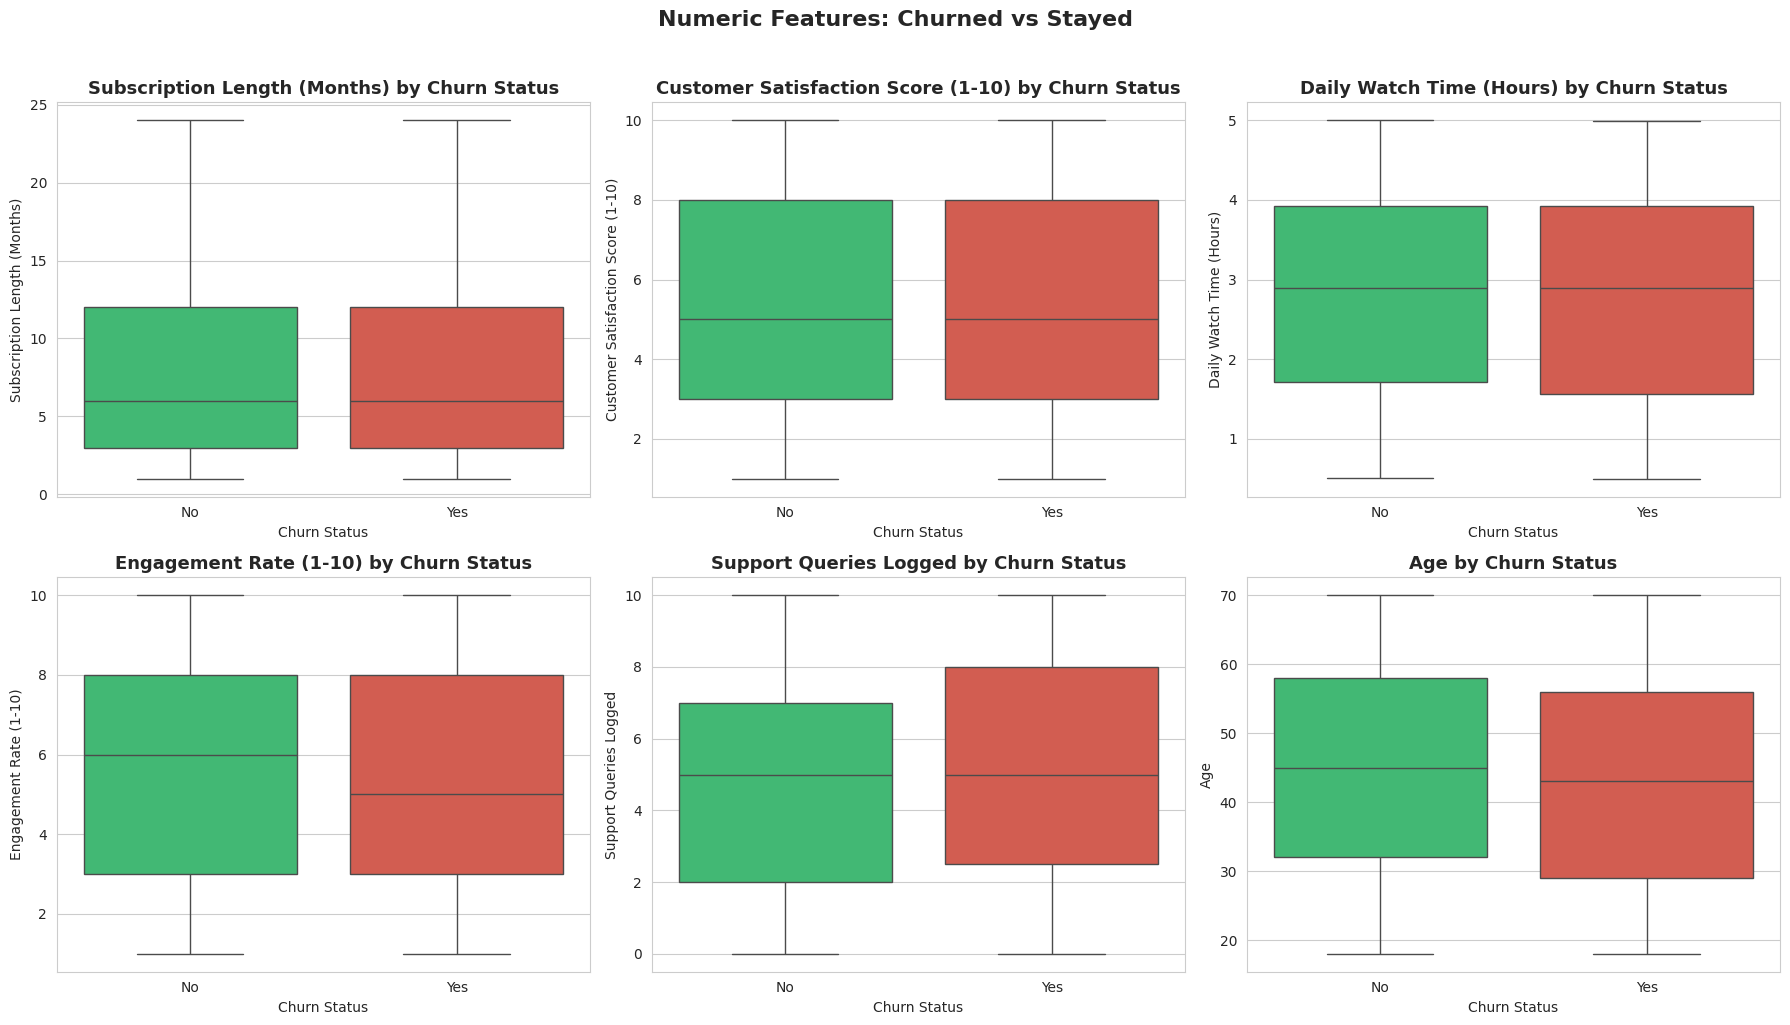

In [29]:
# ============================================================
# EDA CHART 2: NUMERIC FEATURE DISTRIBUTIONS BY CHURN
# Compare distributions for churners vs non-churners
# using box plots — shows median, spread, and outliers.
# ============================================================

# Get numeric columns from raw data
viz_num_cols = df_viz.select_dtypes(include=[np.number]).columns.tolist()
viz_num_cols = [c for c in viz_num_cols if c != TARGET_COL and 'id' not in c.lower()]

plot_num = viz_num_cols[:6]
n_plots = len(plot_num)
n_rows = (n_plots + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    sns.boxplot(data=df_viz, x=TARGET_COL, y=col, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} by Churn Status', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Churn Status')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features: Churned vs Stayed',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Churn Rate by Subscription Plan & Device

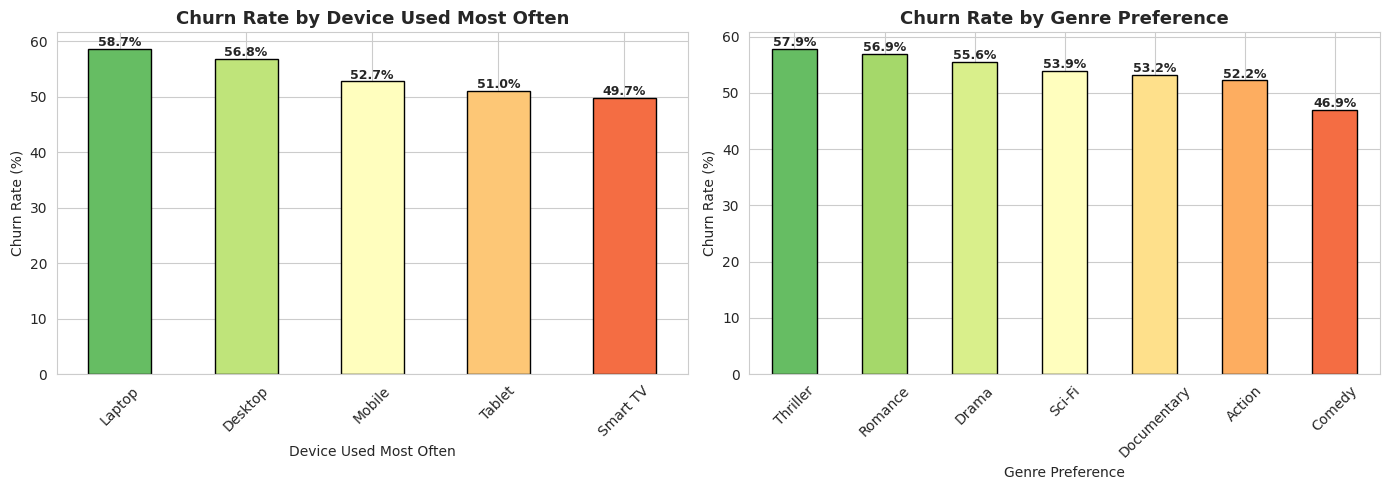

In [30]:
# ============================================================
# EDA CHART 3: CHURN RATE (%) BY KEY CATEGORIES
# Shows the percentage of customers who churned in each group.
# ============================================================

# Pick the two most interesting categorical columns
rate_cols = viz_cat_cols[:2] if len(viz_cat_cols) >= 2 else viz_cat_cols

fig, axes = plt.subplots(1, len(rate_cols), figsize=(7 * len(rate_cols), 5))
if len(rate_cols) == 1:
    axes = [axes]

# Map target to binary for rate calculation
target_values = df_viz[TARGET_COL].unique()
churn_val = [v for v in target_values if any(kw in str(v).lower() for kw in ['yes', 'churn', 'true', '1'])]
churn_val = churn_val[0] if churn_val else target_values[-1]

for i, col in enumerate(rate_cols):
    churn_rate = df_viz.groupby(col)[TARGET_COL].apply(
        lambda x: (x == churn_val).mean() * 100
    ).sort_values(ascending=False)

    bar_colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(churn_rate)))
    churn_rate.plot(kind='bar', ax=axes[i], color=bar_colors, edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(churn_rate):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### 4.4 Correlation Heatmap

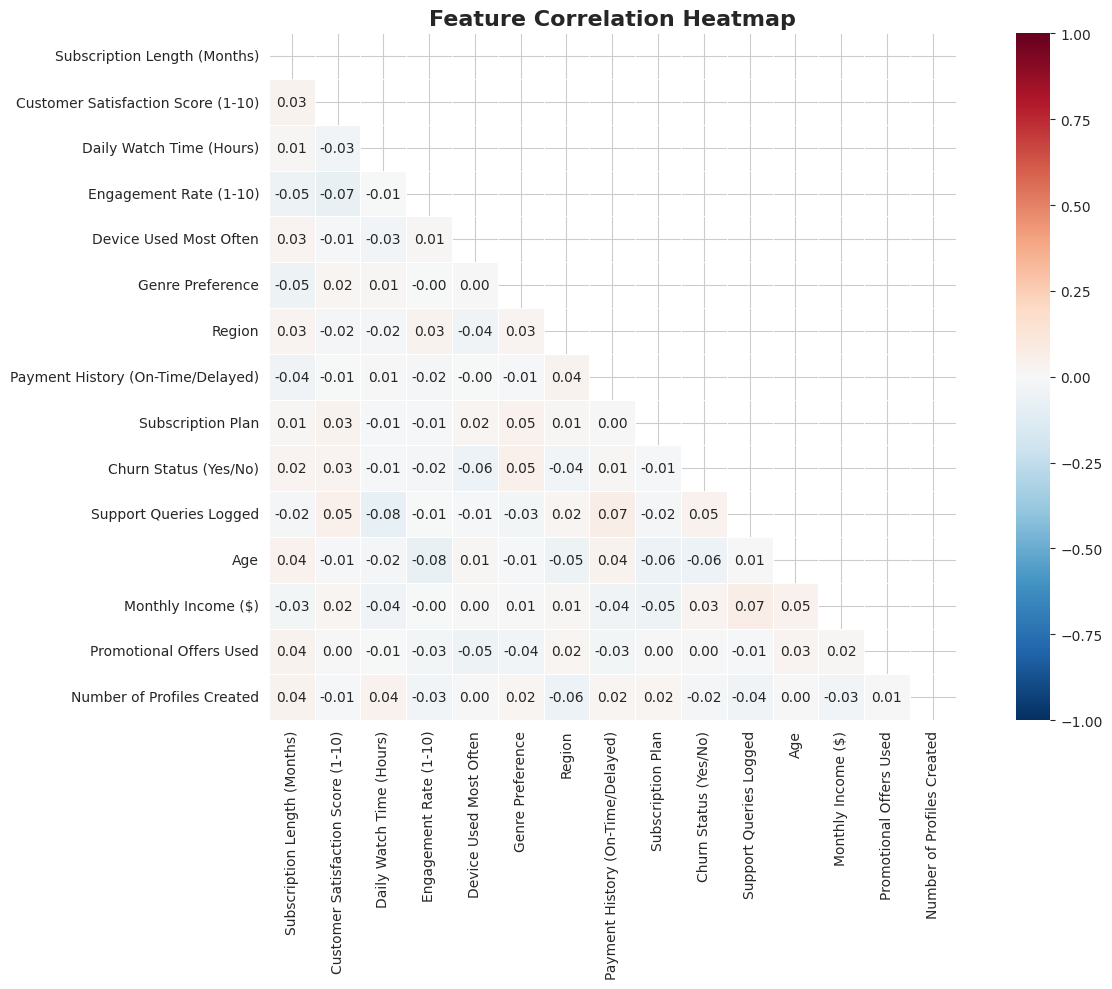

Top Features Correlated with Churn Status (Yes/No):
  Device Used Most Often              : 0.059 (negative)
  Age                                 : 0.055 (negative)
  Genre Preference                    : 0.047 (positive)
  Support Queries Logged              : 0.047 (positive)
  Region                              : 0.035 (negative)
  Monthly Income ($)                  : 0.031 (positive)
  Customer Satisfaction Score (1-10)  : 0.028 (positive)


In [31]:
# ============================================================
# EDA CHART 4: CORRELATION HEATMAP
# Shows how strongly each feature is correlated with Churn.
# Positive = increases churn, Negative = decreases churn.
# ============================================================

plt.figure(figsize=(14, 10))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            vmin=-1, vmax=1, square=True)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show top correlations with target
print(f'Top Features Correlated with {TARGET_COL}:')
churn_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
for feat, val in churn_corr.head(7).items():
    direction = 'positive' if corr_matrix.loc[feat, TARGET_COL] > 0 else 'negative'
    print(f'  {feat:35s} : {val:.3f} ({direction})')

---
## PHASE 5 : HANDLE CLASS IMBALANCE WITH SMOTE
---

### 5.1 Train-Test Split

In [32]:
# ============================================================
# TRAIN-TEST SPLIT (80% train, 20% test)
# We split BEFORE applying SMOTE to prevent data leakage.
# SMOTE should only be applied on the training set.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Before SMOTE:')
print(f'  Training set : {X_train.shape[0]} samples')
print(f'  Testing set  : {X_test.shape[0]} samples')
print(f'  Features     : {X_train.shape[1]}')
print(f'\n  Training class distribution:')
print(f'    No Churn (0): {(y_train == 0).sum()}')
print(f'    Churn    (1): {(y_train == 1).sum()}')
ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f'    Ratio       : {ratio:.1f} : 1')

Before SMOTE:
  Training set : 800 samples
  Testing set  : 200 samples
  Features     : 14

  Training class distribution:
    No Churn (0): 369
    Churn    (1): 431
    Ratio       : 0.9 : 1


### 5.2 Apply SMOTE (Synthetic Minority Oversampling)

After SMOTE:
  Training set : 862 samples (was 800)

  Training class distribution:
    No Churn (0): 431
    Churn    (1): 431
    Ratio       : 1.0 : 1  (Balanced!)


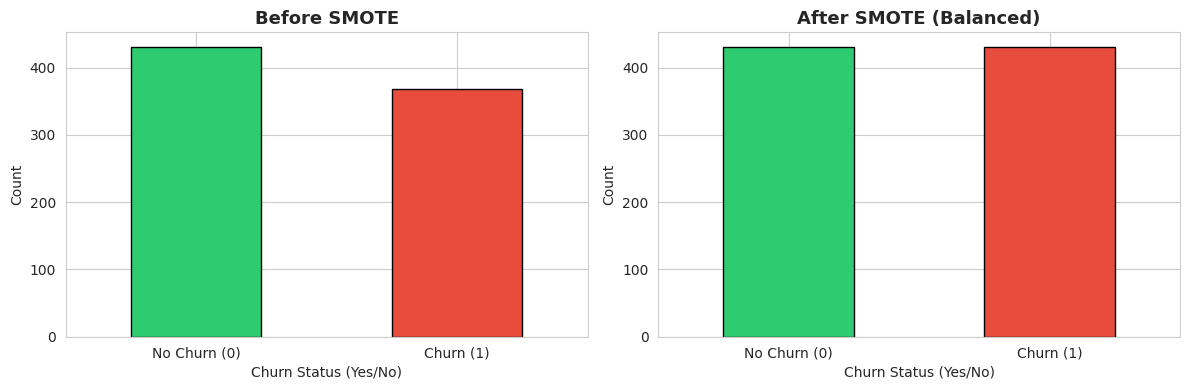

In [33]:
# ============================================================
# SMOTE — Synthetic Minority Oversampling Technique
#
# WHY: If one class dominates, a model could always predict
#      the majority class and still get high accuracy —
#      but miss all actual churners (useless!).
#
# HOW: SMOTE creates synthetic (fake but realistic) samples
#      of the minority class by interpolating between
#      existing minority samples.
#
# RESULT: Both classes become 50-50 in the training data.
# ============================================================

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print('After SMOTE:')
print(f'  Training set : {X_train_balanced.shape[0]} samples (was {X_train.shape[0]})')
print(f'\n  Training class distribution:')
print(f'    No Churn (0): {(y_train_balanced == 0).sum()}')
print(f'    Churn    (1): {(y_train_balanced == 1).sum()}')
print(f'    Ratio       : 1.0 : 1  (Balanced!)')

# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
axes[0].set_ylabel('Count')

y_train_balanced.value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('After SMOTE (Balanced)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## PHASE 6 : MODEL TRAINING
---

### 6.1 Model 1 — Logistic Regression

In [34]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
#
# WHY: Simple, fast, interpretable baseline model.
#      Works well for binary classification problems.
#      Outputs probability scores (not just 0/1).
#
# HOW: Finds a linear decision boundary that separates
#      churners from non-churners in feature space.
# ============================================================

print('Training Logistic Regression...')

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

# Train on SMOTE-balanced data
lr_model.fit(X_train_balanced, y_train_balanced)

# Predict on test set (original, NOT balanced)
lr_pred       = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print('Logistic Regression trained successfully!')

Training Logistic Regression...
Logistic Regression trained successfully!


### 6.2 Model 2 — Random Forest Classifier

In [35]:
# ============================================================
# MODEL 2: RANDOM FOREST CLASSIFIER
#
# WHY: Powerful ensemble model — builds many decision trees
#      and averages their predictions (reduces overfitting).
#      Handles non-linear patterns that LR might miss.
#      Provides feature importance rankings.
#
# PARAMETERS:
#   n_estimators=200  -> 200 decision trees in the forest
#   max_depth=12      -> Limit tree depth to prevent overfitting
#   min_samples_split -> At least 5 samples to split a node
#   n_jobs=-1         -> Use all CPU cores for speed
# ============================================================

print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# Train on SMOTE-balanced data
rf_model.fit(X_train_balanced, y_train_balanced)

# Predict on test set
rf_pred       = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest trained successfully!')

Training Random Forest...
Random Forest trained successfully!


---
## PHASE 7 : MODEL EVALUATION & COMPARISON
---

### 7.1 Evaluation Helper Function

In [36]:
# ============================================================
# EVALUATION FUNCTION
# Computes all metrics and prints a formatted report.
# ============================================================

def evaluate_model(name, y_true, y_pred, y_proba):
    """Evaluate a model and return a dict of metrics."""
    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1 Score' : f1_score(y_true, y_pred),
        'AUC-ROC'  : roc_auc_score(y_true, y_proba)
    }

    print(f'\n{"=" * 50}')
    print(f'  {name} — Performance Metrics')
    print(f'{"=" * 50}')
    for metric, value in metrics.items():
        if metric != 'Model':
            print(f'  {metric:10s} : {value * 100:.2f}%')
    print(f'{"=" * 50}')

    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred,
                                target_names=['No Churn', 'Churn']))
    return metrics

print('Evaluation function defined.')

Evaluation function defined.


### 7.2 Evaluate Logistic Regression

In [37]:
lr_metrics = evaluate_model('Logistic Regression', y_test, lr_pred, lr_pred_proba)


  Logistic Regression — Performance Metrics
  Accuracy   : 48.50%
  Precision  : 52.58%
  Recall     : 47.22%
  F1 Score   : 49.76%
  AUC-ROC    : 49.82%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.45      0.50      0.47        92
       Churn       0.53      0.47      0.50       108

    accuracy                           0.48       200
   macro avg       0.49      0.49      0.48       200
weighted avg       0.49      0.48      0.49       200



### 7.3 Evaluate Random Forest

In [38]:
rf_metrics = evaluate_model('Random Forest', y_test, rf_pred, rf_pred_proba)


  Random Forest — Performance Metrics
  Accuracy   : 50.50%
  Precision  : 54.21%
  Recall     : 53.70%
  F1 Score   : 53.95%
  AUC-ROC    : 53.26%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.46      0.47      0.46        92
       Churn       0.54      0.54      0.54       108

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.51      0.51      0.51       200



### 7.4 Side-by-Side Model Comparison

In [39]:
# ============================================================
# COMPARISON TABLE
# See both models' metrics side by side to pick the best one.
# ============================================================

comparison_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')

comparison_styled = comparison_df.style.format('{:.2%}').background_gradient(
    cmap='Greens', axis=None
)

print('\n========== MODEL COMPARISON ==========')
comparison_df_display = comparison_df.copy()
for col in comparison_df_display.columns:
    comparison_df_display[col] = comparison_df_display[col].apply(lambda x: f'{x*100:.2f}%')
print(comparison_df_display.to_string())

best_model_name = comparison_df['F1 Score'].idxmax()
print(f'\nBest Model (by F1 Score): {best_model_name}')

comparison_styled


========== MODEL COMPARISON ==========
                    Accuracy Precision  Recall F1 Score AUC-ROC
Model                                                          
Logistic Regression   48.50%    52.58%  47.22%   49.76%  49.82%
Random Forest         50.50%    54.21%  53.70%   53.95%  53.26%

Best Model (by F1 Score): Random Forest


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Logistic Regression,48.50%,52.58%,47.22%,49.76%,49.82%
Random Forest,50.50%,54.21%,53.70%,53.95%,53.26%


### 7.5 Confusion Matrices (Side by Side)

Logistic Regression: TN=46  FP=46  FN=57  TP=51
Random Forest: TN=43  FP=49  FN=50  TP=58


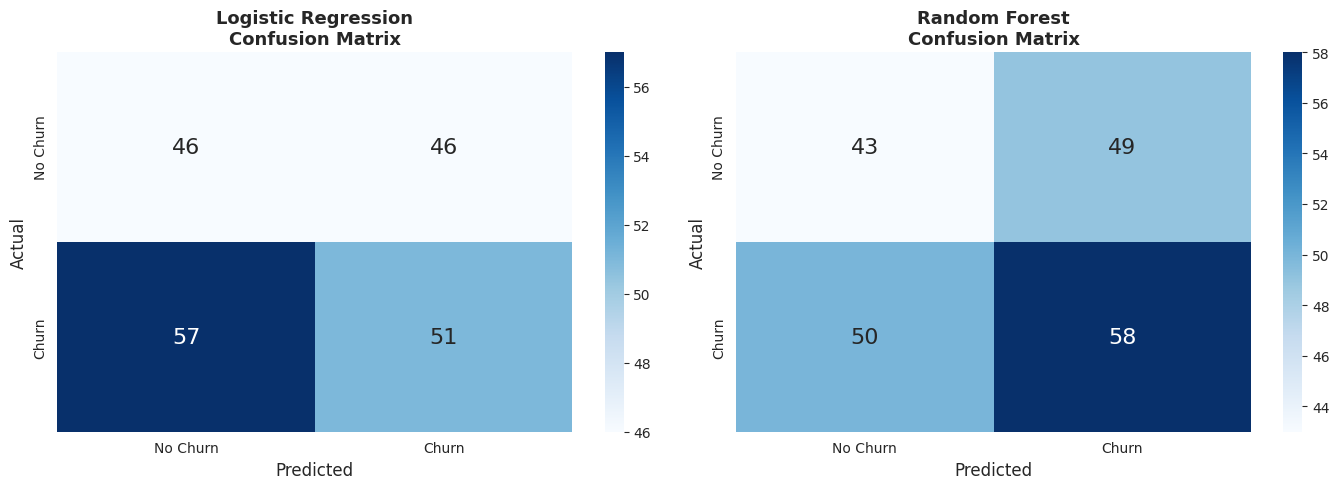

In [40]:
# ============================================================
# CONFUSION MATRICES — Visual comparison of both models
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred)
]

for i, (name, preds) in enumerate(models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                annot_kws={'size': 16})
    axes[i].set_xlabel('Predicted', fontsize=12)
    axes[i].set_ylabel('Actual', fontsize=12)
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')

    tn, fp, fn, tp = cm.ravel()
    print(f'{name}: TN={tn}  FP={fp}  FN={fn}  TP={tp}')

plt.tight_layout()
plt.show()

### 7.6 ROC Curves (Both Models)

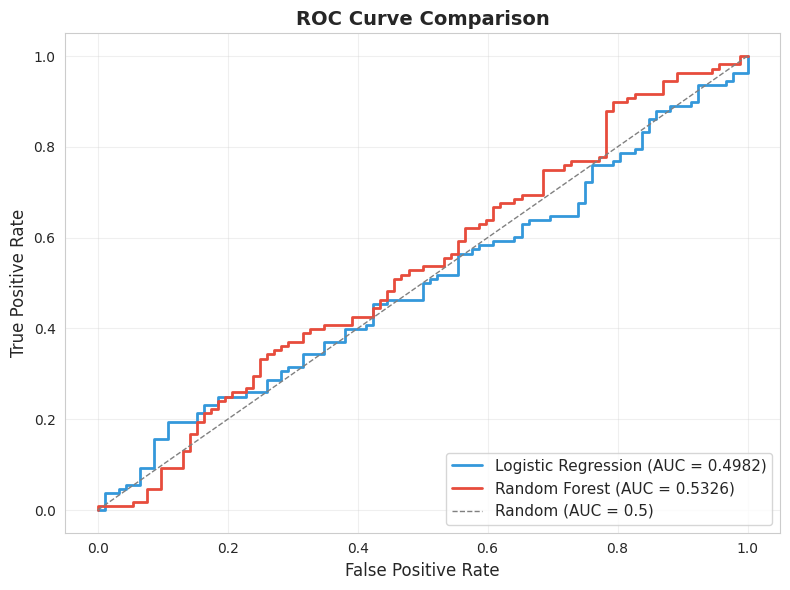

In [41]:
# ============================================================
# ROC CURVE — Receiver Operating Characteristic
# AUC closer to 1.0 = better model.
# ============================================================

plt.figure(figsize=(8, 6))

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
lr_auc = auc(lr_fpr, lr_tpr)
plt.plot(lr_fpr, lr_tpr, color='#3498db', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
rf_auc = auc(rf_fpr, rf_tpr)
plt.plot(rf_fpr, rf_tpr, color='#e74c3c', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.7 Metrics Bar Chart Comparison

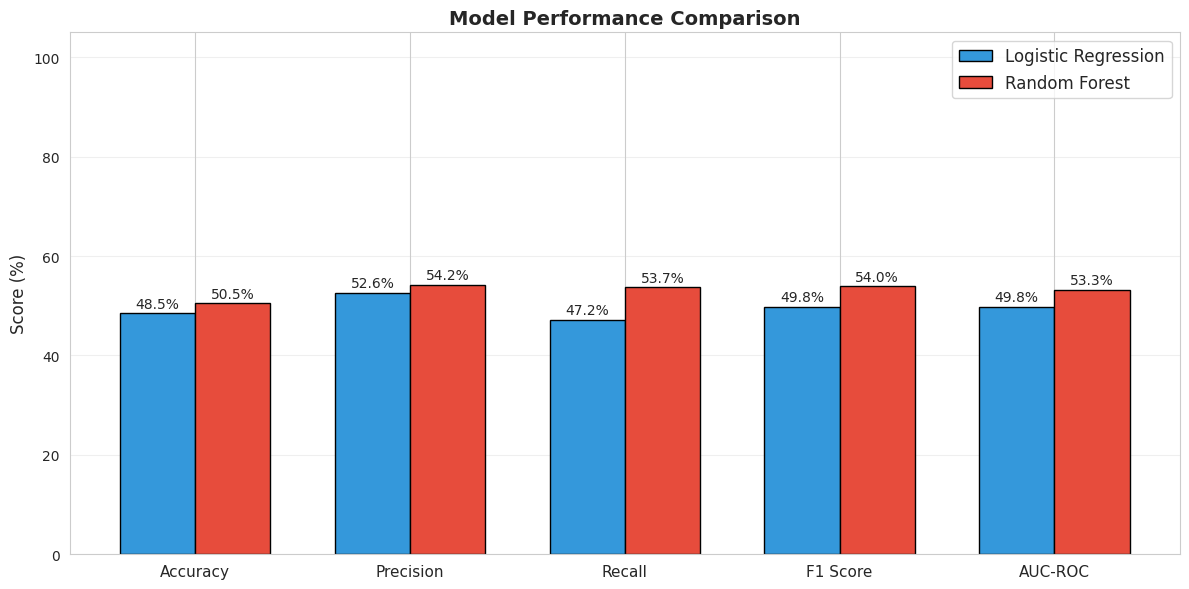

In [42]:
# ============================================================
# METRICS BAR CHART — Compare all metrics visually
# ============================================================

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
lr_scores = [lr_metrics[m] * 100 for m in metrics_names]
rf_scores = [rf_metrics[m] * 100 for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest',
               color='#e74c3c', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=12)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## PHASE 8 : FEATURE IMPORTANCE ANALYSIS
---

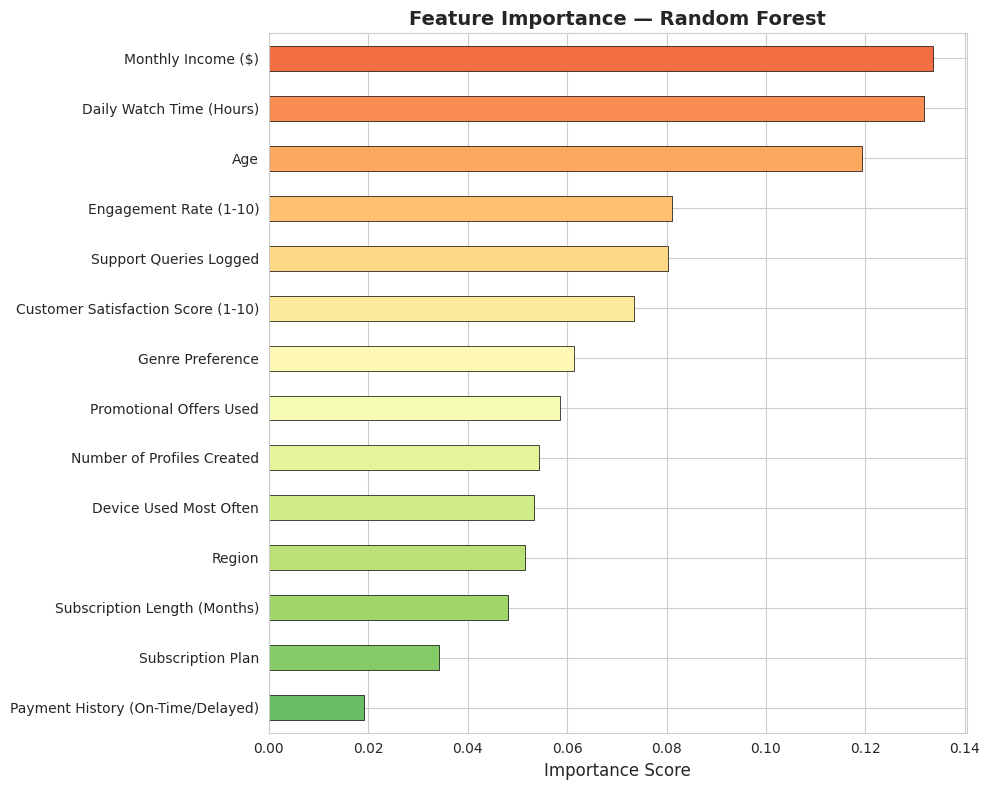

Top 5 Most Important Features for Predicting Churn:
  1. Monthly Income ($): 0.1337
  2. Daily Watch Time (Hours): 0.1317
  3. Age: 0.1193
  4. Engagement Rate (1-10): 0.0810
  5. Support Queries Logged: 0.0803


In [43]:
# ============================================================
# FEATURE IMPORTANCE — RANDOM FOREST
# Ranks features by how much they reduce impurity (Gini).
# ============================================================

feature_imp = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feature_imp)))
feature_imp.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

print('Top 5 Most Important Features for Predicting Churn:')
for i, (feat, imp) in enumerate(feature_imp.sort_values(ascending=False).head().items(), 1):
    print(f'  {i}. {feat}: {imp:.4f}')

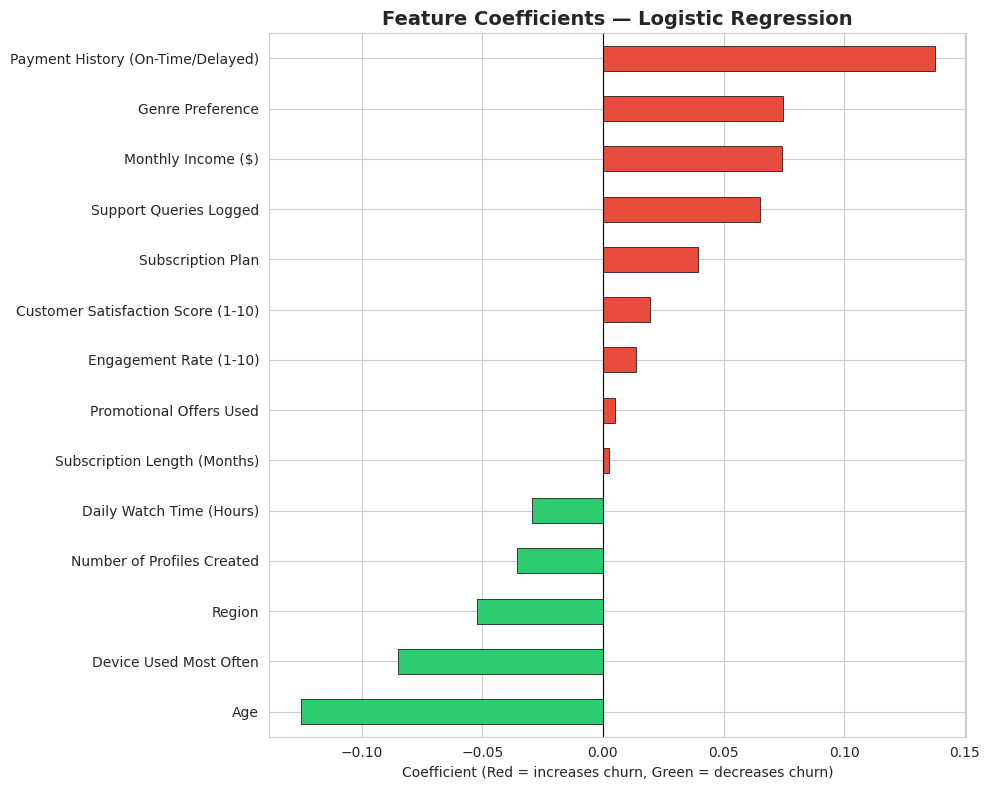

In [44]:
# ============================================================
# FEATURE COEFFICIENTS — LOGISTIC REGRESSION
# Positive = increases churn, Negative = decreases churn.
# ============================================================

lr_coeff = pd.Series(
    lr_model.coef_[0], index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in lr_coeff]
lr_coeff.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.title('Feature Coefficients — Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient (Red = increases churn, Green = decreases churn)', fontsize=10)
plt.ylabel('')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## PHASE 9 
---

### 9.1 Prepare Prediction Results

In [45]:
# ============================================================
# CREATE COMPREHENSIVE RESULTS DATAFRAME
# Contains: original features, predictions from both models,
# churn probabilities, and risk categories.
# ============================================================

test_indices = X_test.index

# Build export from raw (human-readable) data
export_df = df_raw.loc[test_indices].copy()

# Add predictions
export_df['LR_Predicted_Churn']   = lr_pred
export_df['LR_Churn_Probability'] = lr_pred_proba.round(4)
export_df['RF_Predicted_Churn']   = rf_pred
export_df['RF_Churn_Probability'] = rf_pred_proba.round(4)

# Readable labels
export_df['LR_Prediction_Label'] = export_df['LR_Predicted_Churn'].map({1: 'Churn', 0: 'No Churn'})
export_df['RF_Prediction_Label'] = export_df['RF_Predicted_Churn'].map({1: 'Churn', 0: 'No Churn'})

# Risk categories
export_df['Risk_Category'] = pd.cut(
    export_df['RF_Churn_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    include_lowest=True
)

print(f'Export dataframe: {export_df.shape[0]} rows x {export_df.shape[1]} columns')
print(f'\nRisk Category Distribution:')
print(export_df['Risk_Category'].value_counts())

export_df.head(10)

Export dataframe: 200 rows x 23 columns

Risk Category Distribution:
Risk_Category
Medium Risk    179
High Risk       21
Low Risk         0
Name: count, dtype: int64


,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,...,Monthly Income ($),Promotional Offers Used,Number of Profiles Created,LR_Predicted_Churn,LR_Churn_Probability,RF_Predicted_Churn,RF_Churn_Probability,LR_Prediction_Label,RF_Prediction_Label,Risk_Category
787,C00788,6,5,4.97,10,Smart TV,Documentary,Asia,On-Time,Standard,...,5116,2,5,0,0.4997,1,0.5769,No Churn,Churn,Medium Risk
576,C00577,12,5,4.72,6,Mobile,Romance,Africa,On-Time,Standard,...,1614,5,3,1,0.5331,0,0.4490,Churn,No Churn,Medium Risk
880,C00881,3,9,2.11,1,Tablet,Comedy,North America,On-Time,Premium,...,6460,1,3,0,0.3768,0,0.4379,No Churn,No Churn,Medium Risk
288,C00289,12,1,4.77,9,Laptop,Romance,North America,On-Time,Basic,...,8657,1,1,1,0.5918,1,0.5580,Churn,Churn,Medium Risk
337,C00338,3,9,0.63,6,Laptop,Documentary,Europe,On-Time,Premium,...,6243,0,4,1,0.5323,0,0.3783,Churn,No Churn,Medium Risk
80,C00081,1,3,1.06,7,Smart TV,Action,North America,On-Time,Standard,...,1717,4,4,0,0.4226,0,0.4007,No Churn,No Churn,Medium Risk
47,C00048,6,7,0.58,2,Smart TV,Drama,Asia,On-Time,Premium,...,7178,1,3,0,0.4608,0,0.4200,No Churn,No Churn,Medium Risk
202,C00203,6,3,4.79,6,Mobile,Documentary,Africa,On-Time,Premium,...,777,5,2,0,0.4547,0,0.4640,No Churn,No Churn,Medium Risk
41,C00042,24,4,4.70,8,Tablet,Drama,Asia,Delayed,Standard,...,2406,4,5,0,0.4291,1,0.5169,No Churn,Churn,Medium Risk
509,C00510,1,2,4.85,9,Smart TV,Romance,Africa,Delayed,Standard,...,1879,4,1,0,0.4283,1,0.5679,No Churn,Churn,Medium Risk


### 9.2 Save & Download CSV Files

In [46]:
# ============================================================
# EXPORT FILE 1: churn_predictions.csv
# Main file for Power BI — customer-level predictions.
# ============================================================
export_df.to_csv('churn_predictions.csv', index=False)
print(f'1. churn_predictions.csv  ({export_df.shape[0]} rows, {export_df.shape[1]} cols)')

1. churn_predictions.csv  (200 rows, 23 cols)


In [47]:
# ============================================================
# EXPORT FILE 2: model_comparison.csv
# Both models' metrics for KPI cards in dashboard.
# ============================================================
comparison_export = pd.DataFrame([lr_metrics, rf_metrics])
comparison_export.to_csv('model_comparison.csv', index=False)
print('2. model_comparison.csv')
print(comparison_export.to_string(index=False))

2. model_comparison.csv
              Model  Accuracy  Precision   Recall  F1 Score  AUC-ROC
Logistic Regression     0.485   0.525773 0.472222  0.497561 0.498188
      Random Forest     0.505   0.542056 0.537037  0.539535 0.532609


In [48]:
# ============================================================
# EXPORT FILE 3: feature_importance.csv
# Feature rankings for bar charts in dashboard.
# ============================================================
fi_export = pd.DataFrame({
    'Feature': X.columns,
    'RF_Importance': rf_model.feature_importances_,
    'LR_Coefficient': lr_model.coef_[0]
}).sort_values('RF_Importance', ascending=False)

fi_export.to_csv('feature_importance.csv', index=False)
print('3. feature_importance.csv')
fi_export

3. feature_importance.csv


,Feature,RF_Importance,LR_Coefficient
11,Monthly Income ($),0.133672,0.074363
2,Daily Watch Time (Hours),0.131721,-0.029492
10,Age,0.119270,-0.125325
3,Engagement Rate (1-10),0.081033,0.013643
9,Support Queries Logged,0.080317,0.065207
1,Customer Satisfaction Score (1-10),0.073504,0.019312
5,Genre Preference,0.061401,0.074502
12,Promotional Offers Used,0.058534,0.005007
13,Number of Profiles Created,0.054244,-0.035707
4,Device Used Most Often,0.053254,-0.084781


In [49]:
# ============================================================
# EXPORT FILE 4: churn_summary.csv
# Aggregated stats for summary tiles in dashboard.
# ============================================================
total_customers   = len(export_df)
churned_actual    = (export_df[TARGET_COL].isin(['Yes', 'Churned', 1, '1'])).sum()
churned_predicted = (export_df['RF_Predicted_Churn'] == 1).sum()
high_risk         = (export_df['Risk_Category'] == 'High Risk').sum()

summary = pd.DataFrame({
    'Metric': [
        'Total Customers (Test Set)',
        'Actual Churned',
        'Predicted Churned (RF)',
        'High Risk Customers',
        'Churn Rate (%)',
        'Best Model',
        'Best Model Accuracy',
        'Best Model F1 Score'
    ],
    'Value': [
        total_customers,
        churned_actual,
        churned_predicted,
        high_risk,
        f"{churned_actual / total_customers * 100:.1f}",
        best_model_name,
        f"{comparison_df.loc[best_model_name, 'Accuracy']*100:.2f}%",
        f"{comparison_df.loc[best_model_name, 'F1 Score']*100:.2f}%"
    ]
})

summary.to_csv('churn_summary.csv', index=False)
print('4. churn_summary.csv')
summary

4. churn_summary.csv


,Metric,Value
0,Total Customers (Test Set),200
1,Actual Churned,108
2,Predicted Churned (RF),107
3,High Risk Customers,21
4,Churn Rate (%),54.0
5,Best Model,Random Forest
6,Best Model Accuracy,50.50%
7,Best Model F1 Score,53.95%
